# Image Retrieval on CIFAR-10

Given a **query image** and **K**, returns the **K most similar images** from the CIFAR-10 database with their labels.

**Pipeline:**
1. Load a pre-trained ViT/Swin/GCViT model
2. Extract the feature vector of the query image
3. Compute cosine similarity against the entire database
4. Return the K images with the highest similarity scores

## 1. Imports & Configuration

In [21]:
import os
import numpy as np
import pandas as pd
import torch
import timm
import torchvision
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from torch.nn import CosineSimilarity

# ── Configuration ─────────────────────────────────────────────────────────────

# Model name: vit_s16 | swin_s | gcvit_s
MODEL_NAME = "vit_s16"

TIMM_MODELS = {
    "vit_s16": "vit_small_patch16_224.augreg_in1k",
    "swin_s":  "swin_small_patch4_window7_224.ms_in1k",
    "gcvit_s": "gcvit_small.in1k",
}
MODEL_TIMM = TIMM_MODELS[MODEL_NAME]

# Path to pre-extracted database features (pickle file from extract_features.py)
FEATURES_DIR     = "./cifar10_features"
DB_FEATURES_PATH = os.path.join(FEATURES_DIR, f"{MODEL_NAME}_cifar10_train")

DATASET_ROOT = "./datasets/CIFAR-10"

# Must match the weights used when running extract_features.py.
# None → ImageNet pretrained; Path → fine-tuned checkpoint
WEIGHTS = "./model_save/vit_s16_cifar10.pth"

CLASSES = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Model:  {MODEL_NAME} ({MODEL_TIMM})")
print(f"DB features path: {DB_FEATURES_PATH}")
print(f"Weights: {WEIGHTS if WEIGHTS else 'ImageNet pretrained (None)'}")

Device: cuda
Model:  vit_s16 (vit_small_patch16_224.augreg_in1k)
DB features path: ./cifar10_features/vit_s16_cifar10_train
Weights: ./model_save/vit_s16_cifar10.pth


## 2. Load Model & Database Features

In [22]:
if WEIGHTS and not os.path.exists(WEIGHTS):
    raise FileNotFoundError(
        f"Weights file not found: {WEIGHTS}\n"
        "Check the path or set WEIGHTS = None to use ImageNet pretrained weights."
    )

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    free_mem, total_mem = torch.cuda.mem_get_info()
    print(f"GPU VRAM: {free_mem/1024**3:.1f} GB free / {total_mem/1024**3:.1f} GB total")

print(f"Loading model with weights: {WEIGHTS if WEIGHTS else 'ImageNet pretrained'}")
if WEIGHTS:
    model = timm.create_model(MODEL_TIMM, num_classes=0, checkpoint_path=WEIGHTS)
else:
    model = timm.create_model(MODEL_TIMM, pretrained=True, num_classes=0)
model.eval()

# Fall back to CPU if GPU is out of memory
try:
    model.to(device)
    compute_device = device
    print(f"Model loaded on: {compute_device}")
except RuntimeError as e:
    if "out of memory" in str(e).lower() or "AcceleratorError" in str(type(e).__name__):
        torch.cuda.empty_cache()
        compute_device = torch.device("cpu")
        model.to(compute_device)
        print(f"CUDA OOM — falling back to CPU. Model loaded on: {compute_device}")
    else:
        raise

transform = timm.data.create_transform(
    **timm.data.resolve_data_config(model.pretrained_cfg)
)
print(f"Transform: {transform.transforms[0]}, {transform.transforms[1]}, ...")

print("\nLoading database features...")
if not os.path.exists(DB_FEATURES_PATH):
    raise FileNotFoundError(
        f"Features file not found: {DB_FEATURES_PATH}\n"
        f"Run extract_features.py first:  python extract_features.py --model {MODEL_NAME}"
    )

db_df     = pd.read_pickle(DB_FEATURES_PATH)
db_matrix = torch.tensor(
    np.array(db_df[MODEL_NAME].tolist()), dtype=torch.float32
).to(compute_device)                            # [N, D]
db_labels = db_df["labels"].values.astype(int)  # [N]
print(f"Database: {len(db_df):,} images | feature dim: {db_matrix.shape[1]}")

print("\nLoading CIFAR-10 train images...")
cifar_train = torchvision.datasets.CIFAR10(root=DATASET_ROOT, train=True, download=True)
print(f"CIFAR-10 train: {len(cifar_train):,} images")
print("\nReady!")

GPU VRAM: 22.4 GB free / 23.5 GB total
Loading model with weights: ./model_save/vit_s16_cifar10.pth
Model loaded on: cuda
Transform: Resize(size=248, interpolation=bicubic, max_size=None, antialias=True), CenterCrop(size=(224, 224)), ...

Loading database features...
Database: 50,000 images | feature dim: 384

Loading CIFAR-10 train images...
CIFAR-10 train: 50,000 images

Ready!


/home/sotatek/anaconda3/envs/train_ir/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## 3. Feature Extraction & Retrieval Functions

In [23]:
def encode_image(pil_image: Image.Image) -> torch.Tensor:
    """Extract a feature vector from a PIL image."""
    img_tensor = transform(pil_image).unsqueeze(0).to(compute_device)  # [1, C, H, W]
    with torch.no_grad():
        feat = model(img_tensor)  # [1, D]
    return feat.squeeze(0)  # [D]


def retrieve_top_k(
    query_image: Image.Image,
    k: int,
    db_matrix: torch.Tensor,
    db_labels: np.ndarray,
    cifar_dataset,
) -> dict:
    """
    Find the K most similar images to query_image in the CIFAR-10 database.

    Args:
        query_image  : query image (PIL.Image)
        k            : number of results to return
        db_matrix    : database feature matrix [N, D]
        db_labels    : corresponding integer labels [N]
        cifar_dataset: torchvision CIFAR10 dataset (for retrieving original images)

    Returns:
        dict with keys: scores, indices, labels, class_names, images
    """
    query_feat = encode_image(query_image)  # [D]

    cos_sim = CosineSimilarity(dim=1)
    scores  = cos_sim(db_matrix, query_feat.unsqueeze(0))  # [N]

    topk_scores, topk_indices = torch.topk(scores, k=k)
    topk_indices = topk_indices.cpu().numpy()
    topk_scores  = topk_scores.cpu().numpy()

    topk_labels     = db_labels[topk_indices]
    topk_classnames = [CLASSES[lbl] for lbl in topk_labels]
    topk_images     = [cifar_dataset[idx][0] for idx in topk_indices]

    return {
        "scores"     : topk_scores,
        "indices"    : topk_indices,
        "labels"     : topk_labels,
        "class_names": topk_classnames,
        "images"     : topk_images,
    }


def display_results(
    query_image: Image.Image,
    results: dict,
    query_label: int = None,
    figsize_per_img: float = 2.0,
):
    """
    Display the query image alongside the K retrieved results.
    Green border = correct label, red border = wrong label (only when query_label is known).
    """
    k     = len(results["images"])
    ncols = k + 1
    fig, axes = plt.subplots(1, ncols, figsize=(ncols * figsize_per_img, figsize_per_img * 1.6))

    ax = axes[0]
    ax.imshow(query_image)
    title = "QUERY"
    if query_label is not None:
        title += f"\n({CLASSES[query_label]})"
    ax.set_title(title, fontsize=8, fontweight="bold")
    ax.axis("off")
    for spine in ax.spines.values():
        spine.set_edgecolor("blue")
        spine.set_linewidth(3)
        spine.set_visible(True)

    for i, (img, lbl, cls, score) in enumerate(
        zip(results["images"], results["labels"], results["class_names"], results["scores"])
    ):
        ax = axes[i + 1]
        ax.imshow(img)
        ax.set_title(f"#{i+1} {cls}\n{score:.3f}", fontsize=7)
        ax.axis("off")
        if query_label is not None:
            color = "green" if lbl == query_label else "red"
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(2.5)
                spine.set_visible(True)

    if query_label is not None:
        patches = [
            mpatches.Patch(color="green", label="Correct label"),
            mpatches.Patch(color="red",   label="Wrong label"),
        ]
        fig.legend(handles=patches, loc="lower center", ncol=2, fontsize=8,
                   bbox_to_anchor=(0.5, -0.05))

    plt.suptitle(f"Top-{k} retrieval  |  model: {MODEL_NAME}", fontsize=9, y=1.02)
    plt.tight_layout()
    plt.show()


## 4. Query Image & K Selection

K = 10
Query image: /home/sotatek/Documents/Image_Retrieval/image-retrieval-using-transformers/CIFAR10/plane1.jpg


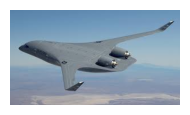

In [38]:
K = 10  # Number of retrieved images
CUSTOM_IMAGE_PATH = "/home/sotatek/Documents/Image_Retrieval/image-retrieval-using-transformers/CIFAR10/plane1.jpg"

query_pil       = Image.open(CUSTOM_IMAGE_PATH).convert("RGB")

print(f"K = {K}")
print(f"Query image: {CUSTOM_IMAGE_PATH}")

plt.figure(figsize=(2, 2))
plt.imshow(query_pil)
plt.axis("off")
plt.tight_layout()
plt.show()



## 5. Retrieval & Results

In [ ]:
import time

t0 = time.time()
results = retrieve_top_k(
    query_image   = query_pil,
    k             = K,
    db_matrix     = db_matrix,
    db_labels     = db_labels,
    cifar_dataset = cifar_train,
)
elapsed = time.time() - t0
print(f"Retrieval completed in {elapsed*1000:.1f} ms\n")

print(f"{'Rank':<6} {'DB Index':<10} {'Label':<8} {'Class':<10} {'Cosine_Sim':<12}")
print("-" * 50)
for rank, (idx, lbl, cls, score) in enumerate(
    zip(results["indices"], results["labels"], results["class_names"], results["scores"]), 1
):
    print(f"{rank:<6} {idx:<10} {lbl:<8} {cls:<10} {score:.4f}")

Retrieval completed in 14.3 ms

Rank   DB Index   Label    Class      Cosine_Sim  
--------------------------------------------------
1      31286      0        plane      0.9828
2      15572      0        plane      0.9828
3      1493       0        plane      0.9827
4      29378      0        plane      0.9826
5      14213      0        plane      0.9808
6      24507      0        plane      0.9807
7      1626       0        plane      0.9803
8      41745      0        plane      0.9802
9      8207       0        plane      0.9800
10     8079       0        plane      0.9800


: 

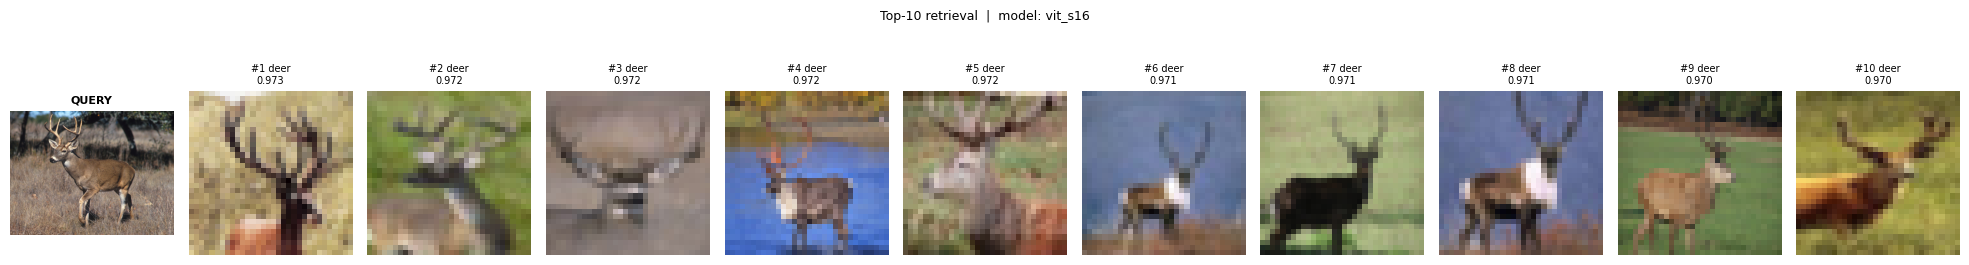

In [ ]:
# Hiển thị ảnh kết quả
display_results(
    query_image  = query_pil,
    results      = results,
    figsize_per_img = 1.8,
)